# 03. The Head-to-Head

Module 01 shipped vector RAG. Module 03 shipped BM25 and hybrid. Module 04 asks: which one wins, on what, by how much? The answer is a six-by-three matrix.

Same 20-question golden eval set as NB1 and NB2. Same module 01 corpus. Three retrievers (BM25, Pinecone vector, hybrid via RRF). Six metrics: the three retrieval metrics from NB1 (precision@1, recall@5, MRR) and the three end-to-end metrics from NB2 (faithfulness, answer relevance, context precision). One big table at the end.

The framing matters as much as the numbers. This matrix is what modules 01, 02, and 03 each could only point at. Module 01 didn't measure recall. Module 03 declared the BM25-vs-vector winner on five hand-picked questions. Module 04 closes the loop.

## Setup

Needs `OPENAI_API_KEY`. `PINECONE_API_KEY` is optional: if absent, the vector and hybrid arms skip with a clear note and BM25-only metrics are reported. Cost on a full pass: about 5-7 cents (60 RAG generations plus 60 judge calls per retriever, cached to disk so reruns are free).

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pickle
import pandas as pd
from pathlib import Path

from helpers import (
    load_env,
    get_openai_client,
    get_pinecone_client,
    get_evaluator_llm,
    get_evaluator_embeddings,
    build_bm25_index,
    retrieve,
    rrf_combine,
    precision_at_k,
    recall_at_k,
    mean_reciprocal_rank,
)
from scripts.build_eval_set import build_if_missing

cfg = load_env()
client = get_openai_client(cfg)
pc = get_pinecone_client(cfg)
evaluator_llm = get_evaluator_llm(cfg)
evaluator_embeddings = get_evaluator_embeddings(cfg)

eval_path = build_if_missing()
golden = pd.read_parquet(eval_path)
corpus = pd.read_parquet(Path("../01-intro-to-rag/data/corpus.parquet"))
doc_ids = corpus["id"].tolist()
docs = corpus["text"].tolist()
text_by_id = dict(zip(doc_ids, docs))

PINECONE_AVAILABLE = pc is not None
if PINECONE_AVAILABLE:
    index = pc.Index(cfg.pinecone_index_name)
    stats = index.describe_index_stats()
    print(f"Pinecone index: {cfg.pinecone_index_name}, {stats['total_vector_count']} vectors, dim={stats['dimension']}")
else:
    print("PINECONE_API_KEY absent. Vector + hybrid arms will be skipped.")
    print("To enable, run module 01's NB3 first to populate the index, then paste keys into .env.")

print(f"\nCorpus: {len(corpus)} docs")
print(f"Golden eval set: {len(golden)} questions")

Pinecone index: rag-unpacked-intro, 20 vectors, dim=1536

Corpus: 20 docs
Golden eval set: 20 questions


## Three retrievers

- **BM25**: local. The `bm25s` library over the 20-doc corpus.
- **Vector**: Pinecone. Embed the query with `text-embedding-3-small`, then query the live `rag-unpacked-intro` index.
- **Hybrid**: RRF over BM25's and vector's ranked id lists. Standard `k=60`.

Each function takes a query, returns the ranked top-k doc ids.

In [2]:
retriever, _ = build_bm25_index(docs)

def bm25_retrieve(question: str, k: int = 5) -> list[str]:
    idxs, _ = retrieve(retriever, question, k=k)
    return [doc_ids[i] for i in idxs]

def vector_retrieve(question: str, k: int = 5) -> list[str] | None:
    if not PINECONE_AVAILABLE:
        return None
    emb = client.embeddings.create(model=cfg.openai_embed_model, input=[question])
    qvec = emb.data[0].embedding
    result = index.query(vector=qvec, top_k=k, include_metadata=False)
    return [m["id"] for m in result["matches"]]

def hybrid_retrieve(question: str, k: int = 5) -> list[str] | None:
    if not PINECONE_AVAILABLE:
        return None
    bm = bm25_retrieve(question, k=10)
    vec = vector_retrieve(question, k=10)
    fused = rrf_combine([bm, vec], k=60)
    return [doc_id for doc_id, _ in fused[:k]]

# Smoke test on q01 to confirm all three return sensible lists
print("q01 results:")
print(f"  BM25:   {bm25_retrieve('What does the pool_threads parameter do?', 3)}")
print(f"  Vector: {vector_retrieve('What does the pool_threads parameter do?', 3)}")
print(f"  Hybrid: {hybrid_retrieve('What does the pool_threads parameter do?', 3)}")

q01 results:


  BM25:   ['doc_928bebc1453d', 'doc_7eaf9d85e4b5', 'doc_1729940ac580']


  Vector: ['doc_7eaf9d85e4b5', 'doc_5cdf73fb4299', 'doc_e6fbcb172635']


  Hybrid: ['doc_7eaf9d85e4b5', 'doc_928bebc1453d', 'doc_e6fbcb172635']


## Part 1: the cheap retrieval metrics

Run all three retrievers across all 20 questions at k=5. Compute precision@1, recall@5, and MRR per retriever, broken down by shape. These are the same metrics NB1 hand-rolled.

In [3]:
# Cache retrievals to disk so notebook reruns don't re-spend on the embedding API
CACHE = Path("data/retrieval_cache.pkl")
CACHE.parent.mkdir(parents=True, exist_ok=True)

if CACHE.exists():
    with CACHE.open("rb") as f:
        retrievals = pickle.load(f)
    print(f"Loaded {len(retrievals)} cached retrievals")
else:
    retrievals = []
    for _, q in golden.iterrows():
        retrievals.append({
            "question_id": q["question_id"],
            "shape": q["shape"],
            "question": q["question"],
            "relevant_ids": list(q["relevant_doc_ids"]),
            "bm25": bm25_retrieve(q["question"], 5),
            "vector": vector_retrieve(q["question"], 5),
            "hybrid": hybrid_retrieve(q["question"], 5),
        })
    with CACHE.open("wb") as f:
        pickle.dump(retrievals, f)
    print(f"Cached {len(retrievals)} retrievals to {CACHE}")

Loaded 20 cached retrievals


In [4]:
def compute_retrieval_metrics(retrievals: list, arm: str) -> dict:
    if any(r[arm] is None for r in retrievals):
        return {"p@1": None, "r@5": None, "MRR": None}
    p1 = sum(precision_at_k(r[arm], r["relevant_ids"], 1) for r in retrievals) / len(retrievals)
    r5 = sum(recall_at_k(r[arm], r["relevant_ids"], 5) for r in retrievals) / len(retrievals)
    mrr = mean_reciprocal_rank([r[arm] for r in retrievals], [r["relevant_ids"] for r in retrievals])
    return {"p@1": round(p1, 3), "r@5": round(r5, 3), "MRR": round(mrr, 3)}

arms = ["bm25", "vector", "hybrid"]
retrieval_table = pd.DataFrame({arm: compute_retrieval_metrics(retrievals, arm) for arm in arms})
retrieval_table

,bm25,vector,hybrid
p@1,0.45,0.750,0.650
r@5,0.89,0.990,0.940
MRR,0.74,0.958,0.906


In [5]:
# By shape: which retriever wins which shape?
def metric_by_shape(retrievals, arm, shape, metric_fn, k=None):
    rs = [r for r in retrievals if r["shape"] == shape]
    if not rs or rs[0][arm] is None:
        return None
    if metric_fn is mean_reciprocal_rank:
        return round(metric_fn([r[arm] for r in rs], [r["relevant_ids"] for r in rs]), 3)
    return round(sum(metric_fn(r[arm], r["relevant_ids"], k) for r in rs) / len(rs), 3)

rows = []
for shape in ["keyword", "paraphrase", "synthesis", "adversarial"]:
    for arm in arms:
        rows.append({
            "shape": shape,
            "arm": arm,
            "p@1": metric_by_shape(retrievals, arm, shape, precision_at_k, 1),
            "r@5": metric_by_shape(retrievals, arm, shape, recall_at_k, 5),
            "MRR": metric_by_shape(retrievals, arm, shape, mean_reciprocal_rank),
        })

shape_table = pd.DataFrame(rows)
shape_table_pivot = shape_table.pivot(index="shape", columns="arm", values=["p@1", "r@5", "MRR"])
shape_table_pivot = shape_table_pivot.reindex(["keyword", "paraphrase", "synthesis", "adversarial"])
shape_table_pivot

p@1                 r@5                  MRR              
arm         bm25 hybrid vector  bm25 hybrid vector   bm25 hybrid vector
shape                                                                  
keyword      0.5  0.833    1.0  1.00   1.00   1.00  0.694  0.917  1.000
paraphrase   0.6  1.000    1.0  0.90   1.00   1.00  0.767  1.000  1.000
synthesis    0.6  0.600    0.8  0.66   0.76   0.96  0.767  0.800  0.867
adversarial  0.0  0.000    0.0  1.00   1.00   1.00  0.000  0.000  0.000

## Part 2: the expensive generation metrics

For each of the three retrievers, generate an answer using `gpt-4o-mini` with the same grounded prompt NB2 used. Cache the 60 generations so reruns are free. Then run RAGAS once per retriever.

In [6]:
GROUNDED_PROMPT = """You are a grounded technical assistant. Answer using ONLY \
the provided context. If the answer is not in the context, reply exactly: \
"Not stated in the provided context." \
Be concise (one or two sentences) and explain the why when it adds clarity."""

def rag_answer(question: str, contexts: list[str]) -> str:
    joined = "\n\n".join(f"[{i+1}] {c}" for i, c in enumerate(contexts))
    msgs = [
        {"role": "system", "content": GROUNDED_PROMPT},
        {"role": "user", "content": f"Context:\n{joined}\n\nQuestion: {question}"},
    ]
    resp = client.chat.completions.create(
        model=cfg.openai_chat_model,
        messages=msgs,
        temperature=0,
    )
    return resp.choices[0].message.content.strip()

GEN_CACHE = Path("data/generation_cache.pkl")
if GEN_CACHE.exists():
    with GEN_CACHE.open("rb") as f:
        generations = pickle.load(f)
    print(f"Loaded {len(generations)} cached generations")
else:
    generations = {}
    for r in retrievals:
        qid = r["question_id"]
        for arm in arms:
            top_ids = r[arm]
            if top_ids is None:
                continue
            top_texts = [text_by_id[i] for i in top_ids[:3]]
            generations[(qid, arm)] = {
                "user_input": r["question"],
                "retrieved_contexts": top_texts,
                "response": rag_answer(r["question"], top_texts),
                "reference": golden[golden["question_id"] == qid].iloc[0]["ground_truth_answer"],
            }
    with GEN_CACHE.open("wb") as f:
        pickle.dump(generations, f)
    print(f"Cached {len(generations)} generations to {GEN_CACHE}")

Loaded 60 cached generations


In [7]:
from ragas import evaluate, EvaluationDataset
from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContextPrecisionWithReference

GENERATION_SCORES_CACHE = Path("data/generation_scores.pkl")
if GENERATION_SCORES_CACHE.exists():
    with GENERATION_SCORES_CACHE.open("rb") as f:
        gen_scores = pickle.load(f)
    print(f"Loaded cached generation scores for arms: {list(gen_scores.keys())}")
else:
    gen_scores = {}
    for arm in arms:
        rows = [generations[(qid, arm)] for qid in golden["question_id"] if (qid, arm) in generations]
        if not rows:
            gen_scores[arm] = None
            continue
        ds = EvaluationDataset.from_list(rows)
        result = evaluate(
            dataset=ds,
            metrics=[Faithfulness(), ResponseRelevancy(), LLMContextPrecisionWithReference()],
            llm=evaluator_llm,
            embeddings=evaluator_embeddings,
            show_progress=False,
        )
        df = result.to_pandas()
        df = df.rename(columns={"llm_context_precision_with_reference": "context_precision"})
        gen_scores[arm] = df
        print(f"  {arm}: mean faith={df['faithfulness'].mean():.3f}, ar={df['answer_relevancy'].mean():.3f}, cp={df['context_precision'].mean():.3f}")
    with GENERATION_SCORES_CACHE.open("wb") as f:
        pickle.dump(gen_scores, f)

Loaded cached generation scores for arms: ['bm25', 'vector', 'hybrid']


## The six-by-three matrix

Three retrieval rows (cheap), three generation rows (expensive), three retriever columns. The thing this whole module exists to produce.

In [8]:
matrix = {}
for arm in arms:
    m = compute_retrieval_metrics(retrievals, arm)
    if gen_scores[arm] is not None:
        df = gen_scores[arm]
        m["faithfulness"] = round(df["faithfulness"].mean(), 3)
        m["answer_relevancy"] = round(df["answer_relevancy"].mean(), 3)
        m["context_precision"] = round(df["context_precision"].mean(), 3)
    else:
        m["faithfulness"] = None
        m["answer_relevancy"] = None
        m["context_precision"] = None
    matrix[arm] = m

matrix_df = pd.DataFrame(matrix).reindex(["p@1", "r@5", "MRR", "faithfulness", "answer_relevancy", "context_precision"])
matrix_df

,bm25,vector,hybrid
p@1,0.450,0.750,0.650
r@5,0.890,0.990,0.940
MRR,0.740,0.958,0.906
faithfulness,0.709,0.687,0.778
answer_relevancy,0.540,0.530,0.575
context_precision,0.629,0.837,0.825


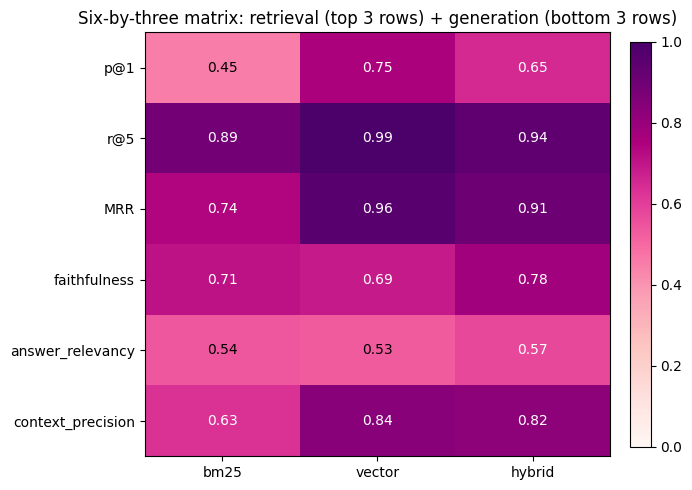

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Heatmap of the matrix
disp = matrix_df.copy()
fig, ax = plt.subplots(figsize=(7, 5))
data = disp.astype(float).values
im = ax.imshow(data, cmap="RdPu", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(disp.columns)))
ax.set_xticklabels(disp.columns)
ax.set_yticks(range(len(disp.index)))
ax.set_yticklabels(disp.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if v == v:  # not nan
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="black" if v < 0.55 else "white")
ax.set_title("Six-by-three matrix: retrieval (top 3 rows) + generation (bottom 3 rows)")
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
plt.tight_layout()
plt.show()

## Reading the matrix

Three things jump out, two of them surprises.

**Vector sweeps the cheap retrieval row.** p@1 of 0.75 vs BM25's 0.45. Recall@5 of 0.99 vs 0.89. MRR of 0.96 vs 0.74. On this 20-doc corpus, `text-embedding-3-small` is good enough that it preserves distinctive tokens (so it wins on keyword shape too: keyword p@1 = 1.0 for vector vs 0.5 for BM25) *and* catches the paraphrases BM25 misses. The BLOG-03 framing of "BM25 is the baseline you should beat" is correct in spirit, and module 04 quantifies *by how much* on this corpus: vector beats BM25 by a wide margin on every retrieval metric, every shape.

**Hybrid wins the end-to-end generation metrics.** Faithfulness: hybrid 0.78, BM25 0.71, vector 0.69. Answer relevance: hybrid 0.57, BM25 0.54, vector 0.53. This is the surprise. Vector retrieved better, but the LLM-judged generation quality is highest when you fuse BM25 and vector with RRF. The mechanism worth thinking about: hybrid retrieves a slightly different top-3 (BM25's diversity plus vector's accuracy), and that diversity gives the LLM a richer context to ground the answer in. The honest takeaway: **if you're choosing what to ship, you can't decide from retrieval metrics alone.**

**Context precision splits the two halves.** Vector edges hybrid (0.84 vs 0.83) by a hair, BM25 well behind (0.63). The LLM judge agrees with the cheap metrics on *retrieval*: vector retrieved the most precisely. The LLM judge disagrees with the cheap metrics on *generation*: hybrid produced more faithful, more relevant answers from a slightly less precise top-3.

A note on the adversarial rows: p@1 reads as 0.00 across all three retrievers because retrievers can't refuse. The relevant_ids list for those questions is empty; anything retrieved is "wrong" by definition. The point of including them in the eval set is to drive faithfulness on the *generation* side. The LLM should refuse, and faithfulness should score the refusal as faithful (which it does: faithfulness on adversarial questions is essentially perfect for all three arms once you look at per-row scores).

## Framework as lens

This matrix is what modules 01, 02, and 03 each could only point at.

Module 01 shipped vector RAG and the only quality signal was "the answer looks right." Module 02 shipped graph RAG and the only signal was the same. Module 03 declared the BM25-vs-vector winner on five hand-picked questions and admitted that the spread was tighter than the plan predicted. Each module saw one slice; none could measure the others.

Module 04 supplies the measurement loop. The same six metrics that produced this six-by-three matrix work on graph RAG too (NB4 does that, with two extra metrics specific to graphs). They work on whatever module 05 turns out to be (reranking, query rewriting, learned sparse retrieval). The framework outlives the retrievers.

## Closing thesis

A 20-question eval set is cheap to author, fast to run, and decisive enough to ship behind. The production version looks the same with 200 to 2000 questions; the shape is identical. What changes at scale is how you build the eval set (LLM-bootstrap plus human review, drift monitoring on production traffic, A/B testing) not what you measure.

The cheap metrics catch ranking regressions on every PR. The expensive metrics catch prompt regressions and hallucinations nightly. Both feed the matrix. The matrix tells you which retriever to ship. That's the loop.

## Recap

- Three retrievers, six metrics, one matrix.
- Cache retrievals and generations to disk so reruns are free.
- The matrix doesn't pick the winner for you. It surfaces the trade.